In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv("data/StudentsPerformance.csv")

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
X=df.drop(columns=['math score'])
X

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [13]:
y=df['math score']

In [16]:
num_features=X.select_dtypes(exclude='str').columns
cat_features=X.select_dtypes(include='str').columns
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder()

preprocessor=ColumnTransformer([
    ("OneHotEncoder",oh_transformer,cat_features),
    ("StandardScaler",numeric_transformer,num_features),
])


In [17]:
X=preprocessor.fit_transform(X)

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((800, 19), (200, 19))

In [24]:
def evaluate_model(true,predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mean_squared_error(true,predicted))
    r2=r2_score(true,predicted)
    return mae,mse,rmse,r2

In [26]:
models={
    "LinearRegression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "KNeighborsRegressor":KNeighborsRegressor(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(verbose=False),
    "AdaBoostRegressor":AdaBoostRegressor()

}
model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    model_train_mae,model_train_mse,model_train_rmse,model_train_r2=evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_mse,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)

    model_list.append(list(models.keys())[i])

    print("Model Performance for Training Set")
    print("RMSE:{:.4f}".format(model_train_rmse))
    print("MSE:{:.4f}".format(model_train_mse))
    print("MAE:{:.4f}".format(model_train_mae))
    print("R2 SCORE:{:.4f}".format(model_train_r2))


    print("-----------------------------")


    print("Model Performance for Testing Set")
    print("RMSE:{:.4f}".format(model_test_rmse))
    print("MSE:{:.4f}".format(model_test_mse))
    print("MAE:{:.4f}".format(model_test_mae))
    print("R2 SCORE:{:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

    print("="*35)
    print("\n")

Model Performance for Training Set
RMSE:5.3231
MSE:28.3349
MAE:4.2667
R2 SCORE:0.8743
-----------------------------
Model Performance for Testing Set
RMSE:5.3940
MSE:29.0952
MAE:4.2148
R2 SCORE:0.8804


Model Performance for Training Set
RMSE:6.5938
MSE:43.4784
MAE:5.2063
R2 SCORE:0.8071
-----------------------------
Model Performance for Testing Set
RMSE:6.5197
MSE:42.5064
MAE:5.1579
R2 SCORE:0.8253


Model Performance for Training Set
RMSE:5.3233
MSE:28.3378
MAE:4.2650
R2 SCORE:0.8743
-----------------------------
Model Performance for Testing Set
RMSE:5.3904
MSE:29.0563
MAE:4.2111
R2 SCORE:0.8806


Model Performance for Training Set
RMSE:5.7079
MSE:32.5799
MAE:4.5168
R2 SCORE:0.8555
-----------------------------
Model Performance for Testing Set
RMSE:7.2530
MSE:52.6066
MAE:5.6210
R2 SCORE:0.7838


Model Performance for Training Set
RMSE:0.2795
MSE:0.0781
MAE:0.0187
R2 SCORE:0.9997
-----------------------------
Model Performance for Testing Set
RMSE:7.4639
MSE:55.7100
MAE:5.9500
R2 S

In [27]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=["Model Name","R2_Score"]).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,LinearRegression,0.880433
8,AdaBoostRegressor,0.852573
7,CatBoostRegressor,0.851632
5,RandomForestRegressor,0.851203
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,KNeighborsRegressor,0.783813
4,DecisionTreeRegressor,0.771060


In [28]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test,y_pred)*100
print("Accuracy of The Model is {:.4f}".format(score))

Accuracy of The Model is 88.0433


Text(0, 0.5, 'Predicted')

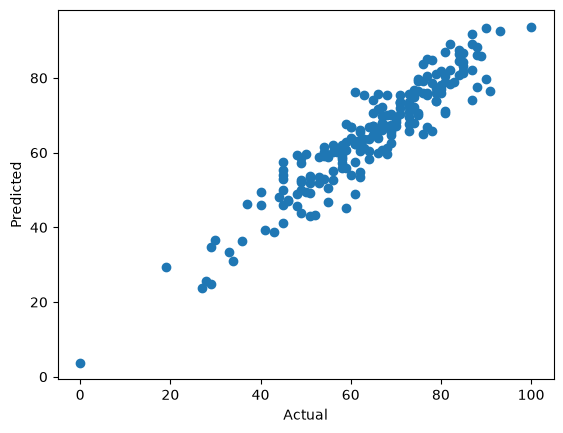

In [29]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math score'>

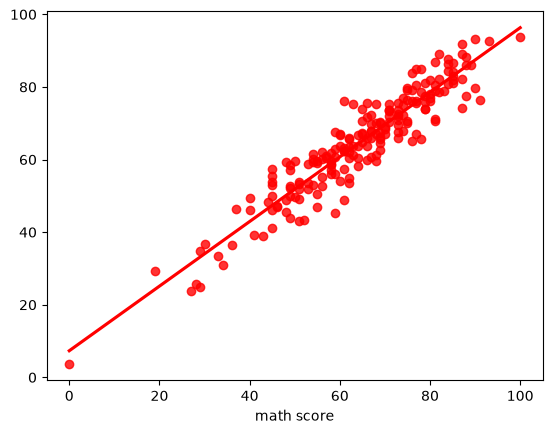

In [30]:
sns.regplot(x=y_test,y=y_pred,ci=None,color="red")

In [32]:
pred_df=pd.DataFrame({"Actual Value":y_test,"Predicted Value":y_pred,"Difference":y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
